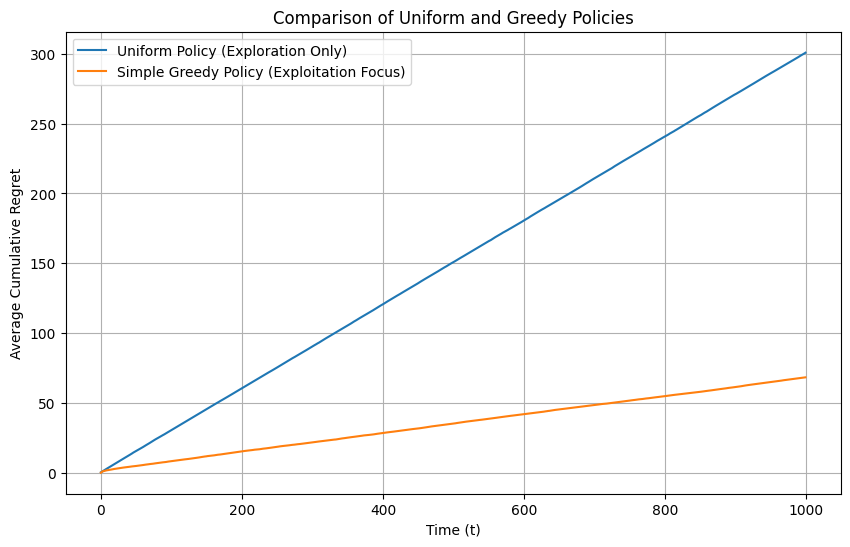

In [3]:
import numpy as np
import matplotlib.pyplot as plt

K = 3  
MEANS = [0.8, 0.5, 0.2]  
BEST_MEAN = max(MEANS)  
T = 1000  
N_TRIALS =500  

def get_reward(arm_index):
    return np.random.binomial(1, MEANS[arm_index])

def run_simulation(policy_type):
    all_regrets = np.zeros((N_TRIALS, T))
    
    for n in range(N_TRIALS):
        arm_counts = np.zeros(K)  
        arm_rewards = np.zeros(K)  
        cumulative_reward = 0
        
        for t in range(1, T + 1):
            if policy_type == 'uniform':
                chosen_arm =np.random.randint(0, K)
                
            elif policy_type == 'greedy':
                if t <= K:
                    chosen_arm = t - 1
                else:
                    emp_means = arm_rewards / arm_counts
                    max_val = np.max(emp_means)
                    
                    indices = np.where(emp_means == max_val)[0]
                    chosen_arm = np.random.choice(indices)
            
            # دریافت پاداش و به‌روزرسانی آمار
            reward = get_reward(chosen_arm)
            arm_counts[chosen_arm] += 1
            arm_rewards[chosen_arm] += reward
            cumulative_reward += reward
            

            all_regrets[n, t-1] = (t * BEST_MEAN) - cumulative_reward
    return np.mean(all_regrets, axis=0)


avg_regret_uniform = run_simulation('uniform')
avg_regret_greedy = run_simulation('greedy')


plt.figure(figsize=(10, 6))
plt.plot(avg_regret_uniform, label='Uniform Policy (Exploration Only)')
plt.plot(avg_regret_greedy, label='Simple Greedy Policy (Exploitation Focus)')
plt.xlabel('Time (t)')
plt.ylabel('Average Cumulative Regret')
plt.title('Comparison of Uniform and Greedy Policies')
plt.legend()
plt.grid(True)
plt.show()

n          p_hat (Experimental)      b_n (Hoeffding Bound)    
-----------------------------------------------------------------
20         0.351050                  1.340640                 
50         0.127950                  0.735759                 
100        0.028860                  0.270671                 
500        0.000000                  0.000091                 


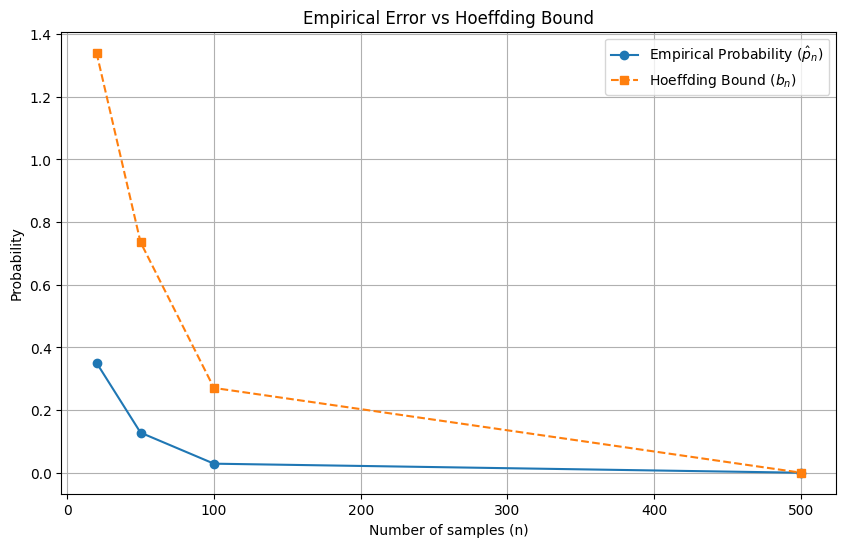

In [10]:
import numpy as np
import matplotlib.pyplot as plt

m = 0.7
epsilon = 0.1
n_values = [20, 50, 100,500]
N_trials = 100000

p_hat_values = []
b_n_values = []

for n in n_values:
    samples = np.random.binomial(1, m, size=(N_trials, n))
    
    sample_means = np.mean(samples, axis=1)
    
    errors= np.abs(sample_means - m) >= epsilon
    p_hat = np.mean(errors)
    p_hat_values.append(p_hat)
    
    b_n = 2 * np.exp(-2 * n * (epsilon**2))
    b_n_values.append(b_n)

print(f"{'n':<10} {'p_hat (Experimental)':<25} {'b_n (Hoeffding Bound)':<25}")
print("-" * 65)
for i in range(len(n_values)):
    print(f"{n_values[i]:<10} {p_hat_values[i]:<25.6f} {b_n_values[i]:<25.6f}")

plt.figure(figsize=(10, 6))
plt.plot(n_values, p_hat_values,'o-', label=r'Empirical Probability ($\hat{p}_n$)')
plt.plot(n_values, b_n_values, 's--', label=r'Hoeffding Bound ($b_n$)')
plt.xlabel('Number of samples (n)')
plt.ylabel('Probability')
plt.title('Empirical Error vs Hoeffding Bound')
plt.legend()
plt.grid(True)
plt.show()

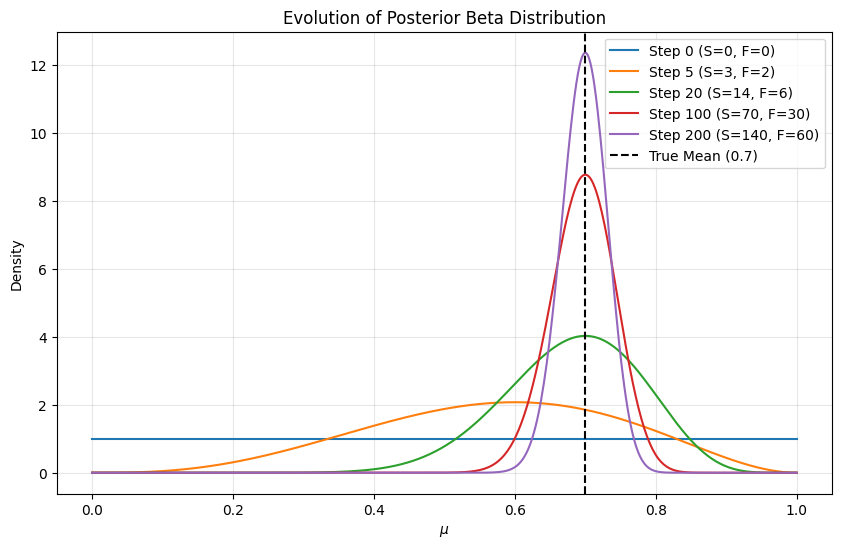

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta


true_mu = 0.7
steps = [0, 5, 20, 100, 200]
alpha_0, beta_0 = 1, 1 

np.random.seed(42)
rewards = np.random.binomial(1, true_mu,max(steps))

x = np.linspace(0, 1, 500)
plt.figure(figsize=(10, 6))

for step in steps:
    current_rewards = rewards[:step]
    successes = sum(current_rewards)
    failures = step - successes
    
    current_alpha = alpha_0 + successes
    current_beta = beta_0 + failures
    
    y = beta.pdf(x, current_alpha, current_beta)
    plt.plot(x, y, label=f'Step {step} (S={successes}, F={failures})')

plt.axvline(true_mu, color='black', linestyle='--', label=f'True Mean ({true_mu})')
plt.title('Evolution of Posterior Beta Distribution')
plt.xlabel(r'$\mu$')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
C:\Users\r1504\AppData\Local\Temp\ipykernel_13916\2333068399.py:63: SyntaxWarning: invalid escape sequence '\m'
  axes[1].plot(history_means[:, i], label=f'Arm {i} (True $\mu$={true_probs[i]})')


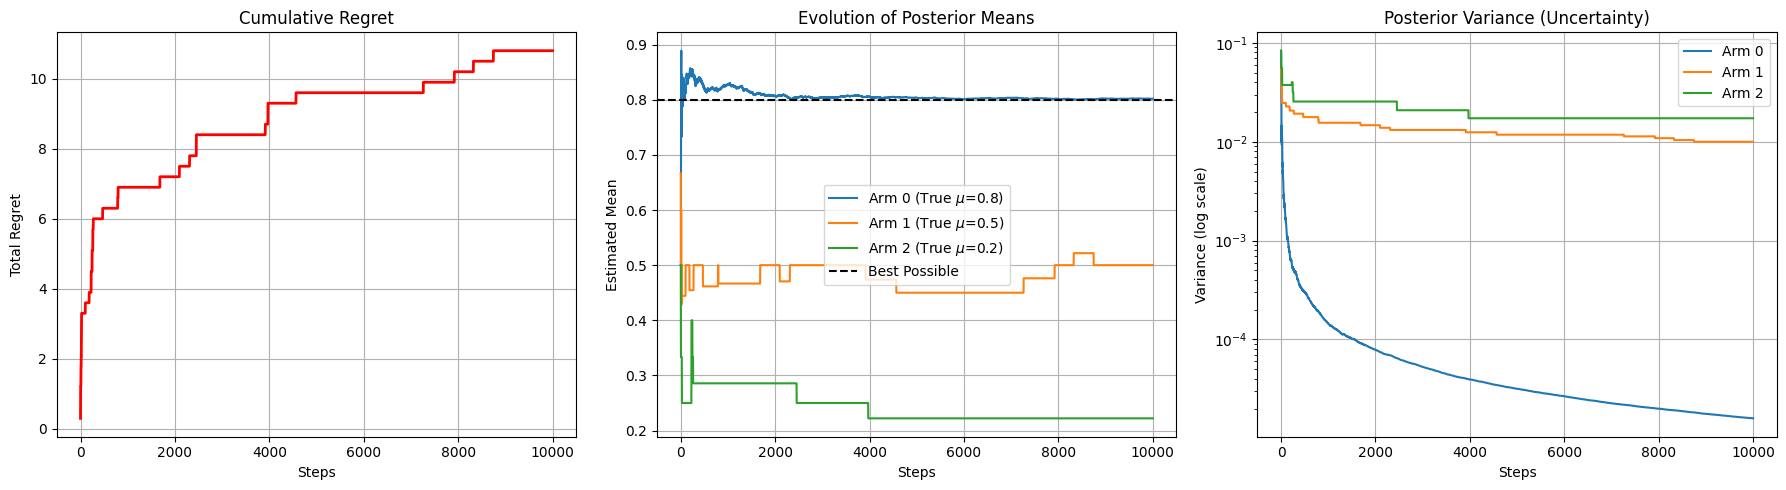

In [3]:
import numpy as np
import matplotlib.pyplot as plt

T = 10000
true_probs =[0.8, 0.5, 0.2]  
k = len(true_probs)

alphas = np.ones(k)
betas = np.ones(k)

cumulative_regret = np.zeros(T)
avg_regret = 0
history_means = []
history_vars = []

for t in range(T):
    samples = [np.random.beta(alphas[i], betas[i]) for i in range(k)]
    
    chosen_arm = np.argmax(samples)
    
    reward = np.random.binomial(1, true_probs[chosen_arm])
    
    if reward == 1:
        alphas[chosen_arm] += 1
    else:
        betas[chosen_arm] += 1
        
    avg_regret += (max(true_probs) - true_probs[chosen_arm])
    cumulative_regret[t] = avg_regret
    
    current_means = alphas / (alphas + betas)
    current_vars = (alphas * betas) / ((alphas + betas)**2 * (alphas + betas + 1))
    
    history_means.append(current_means.copy())
    history_vars.append(current_vars.copy())

history_means = np.array(history_means)
history_vars = np.array(history_vars)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cumulative_regret, color='red', linewidth=2)
axes[0].set_title("Cumulative Regret")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Total Regret")
axes[0].grid(True)

for i in range(k):
    axes[1].plot(history_means[:, i], label=f'Arm{i} (True $\mu$={true_probs[i]})')
axes[1].axhline(y=max(true_probs), color='black', linestyle='--', label='Best Possible')
axes[1].set_title("Evolution of Posterior Means")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Estimated Mean")
axes[1].legend()
axes[1].grid(True)

for i in range(k):
    axes[2].plot(history_vars[:, i], label=f'Arm {i}')
axes[2].set_yscale('log') # مقیاس لگاریتمی برای نمایش بهتر کاهش واریانس
axes[2].set_title("Posterior Variance (Uncertainty)")
axes[2].set_xlabel("Steps")
axes[2].set_ylabel("Variance (log scale)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

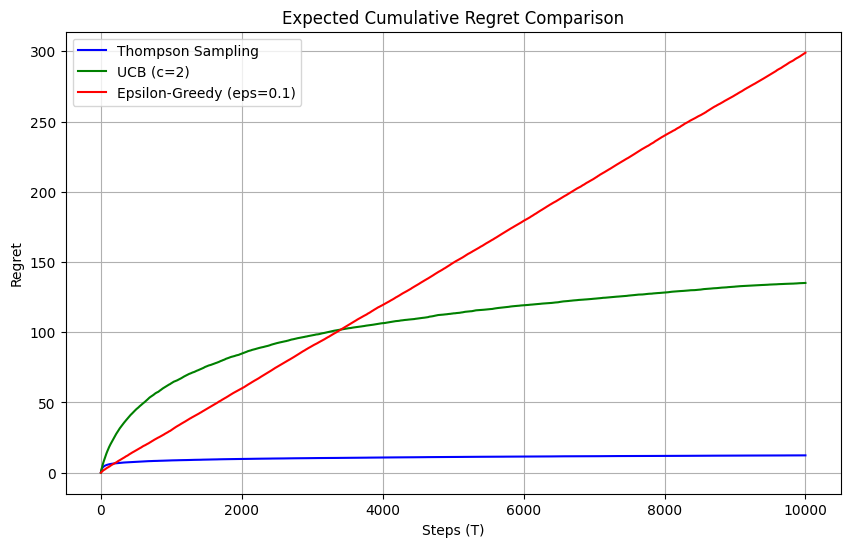

In [6]:
import numpy as np
import matplotlib.pyplot as plt

T = 10000
true_probs = [0.8, 0.5, 0.2]
k = len(true_probs)
best_mu = max(true_probs)
num_experiments = 100 

def run_thompson_sampling(T, true_probs):
    alphas = np.ones(k)
    betas = np.ones(k)
    regret = np.zeros(T)
    cum_regret = 0
    for t in range(T):
        samples = [np.random.beta(alphas[i], betas[i]) for i in range(k)]
        chosen_arm = np.argmax(samples)
        reward = np.random.binomial(1, true_probs[chosen_arm])
        if reward == 1: alphas[chosen_arm] += 1
        else: betas[chosen_arm] += 1
        cum_regret +=(best_mu - true_probs[chosen_arm])
        regret[t] = cum_regret
    return regret

def run_ucb(T, true_probs, c=2):
    counts = np.zeros(k)
    values = np.zeros(k)
    regret = np.zeros(T)
    cum_regret = 0
    
    for t in range(k):
        reward = np.random.binomial(1, true_probs[t])
        counts[t] += 1
        values[t] = reward
        cum_regret += (best_mu - true_probs[t])
        regret[t] = cum_regret

    for t in range(k, T):
        # فرمول UCB: میانگین + کران بالا
        ucb_values = values + c * np.sqrt(np.log(t+1) / counts)
        chosen_arm = np.argmax(ucb_values)
        reward = np.random.binomial(1, true_probs[chosen_arm])
        counts[chosen_arm] += 1
        values[chosen_arm] = ((counts[chosen_arm]-1)*values[chosen_arm] + reward) / counts[chosen_arm]
        cum_regret += (best_mu - true_probs[chosen_arm])
        regret[t] = cum_regret
    return regret



def run_epsilon_greedy(T, true_probs, epsilon=0.1):
    counts = np.zeros(k)
    values = np.zeros(k)
    regret = np.zeros(T)
    cum_regret = 0
    for t in range(T):
        if np.random.random() <= epsilon:
            chosen_arm = np.random.randint(k) # اکتشاف
        else:
            chosen_arm = np.argmax(values) # بهره‌برداری
        
        reward = np.random.binomial(1, true_probs[chosen_arm])
        counts[chosen_arm] += 1
        values[chosen_arm] = ((counts[chosen_arm]-1)*values[chosen_arm] + reward) / counts[chosen_arm]
        cum_regret += (best_mu - true_probs[chosen_arm])
        regret[t] = cum_regret
    return regret


total_ts_regret = np.zeros(T)
total_ucb_regret = np.zeros(T)
total_eps_regret = np.zeros(T)

for i in range(num_experiments):
    total_ts_regret += run_thompson_sampling(T, true_probs)
    total_ucb_regret += run_ucb(T, true_probs)
    total_eps_regret += run_epsilon_greedy(T, true_probs)

# (میانگین نهایی)
avg_ts_regret = total_ts_regret / num_experiments
avg_ucb_regret = total_ucb_regret / num_experiments
avg_eps_regret = total_eps_regret / num_experiments


plt.figure(figsize=(10, 6))
plt.plot(avg_ts_regret, label='Thompson Sampling', color='blue')
plt.plot(avg_ucb_regret, label='UCB (c=2)', color='green')
plt.plot(avg_eps_regret, label='Epsilon-Greedy (eps=0.1)', color='red')
plt.title("Expected Cumulative Regret Comparison")
plt.xlabel("Steps (T)")
plt.ylabel("Regret")
plt.legend()
plt.grid(True)
plt.show()

T       | Arm   | Estimated Prob  | Selection Freq 
-------------------------------------------------------
500     | 0     | 0.0006          | 0.0180         
500     | 1     | 0.0380          | 0.0680         
500     | 2     | 0.9614          | 0.9140         
-------------------------------------------------------
1000    | 0     | 0.0071          | 0.0170         
1000    | 1     | 0.0070          | 0.0530         
1000    | 2     | 0.9859          | 0.9300         
-------------------------------------------------------
5000    | 0     | 0.0003          | 0.0008         
5000    | 1     | 0.0010          | 0.0066         
5000    | 2     | 0.9988          | 0.9926         
-------------------------------------------------------


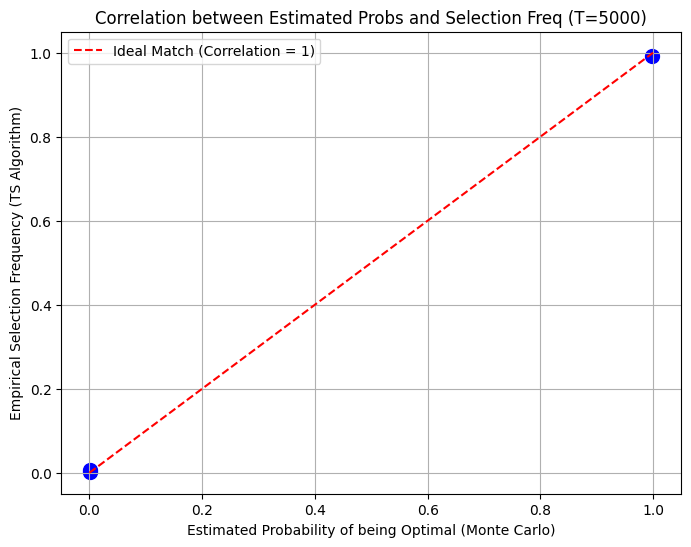

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def estimate_prob_optimal(alphas, betas, n_samples=20000):
    k = len(alphas)
samples =np.zeros((n_samples, k))
    
    for i in range(k):
        samples[:, i] = np.random.beta(alphas[i], betas[i], size=n_samples)
    
    # پیدا کردن بازویی که در هر نمونه بیشترین مقدار را دارد
    max_indices = np.argmax(samples, axis=1)
    
    # محاسبه فراوانی (احتمال) برای هر بازو
    probs = np.zeros(k)
    for i in range(k):
        probs[i] = np.sum(max_indices == i) / n_samples
        
    return probs

# پیاده‌سازی الگوریتم Thompson Sampling و ثبت آمار
def run_ts_simulation(true_mus, T):
    k = len(true_mus)
    alphas = np.ones(k)  # شروع از پیشین Beta(1,1)
    betas = np.ones(k)

    
    arm_selections = np.zeros(k) # تعداد دفعاتی که هر بازو واقعاً انتخاب شده
    
    for t in range(1,T + 1):
        theta_samples = [np.random.beta(alphas[i], betas[i]) for i in range(k)]
        
        chosen_arm = np.argmax(theta_samples)
        arm_selections[chosen_arm] += 1
        
        reward = np.random.binomial(1, true_mus[chosen_arm])
        
        if reward == 1:
            alphas[chosen_arm] += 1
        else:
            betas[chosen_arm]+= 1
            
    # محاسبه فراوانی تجربی انتخاب (Empirical Frequency)
    selection_frequencies = arm_selections / T
    
    # تخمین احتمال بهینه بودن با مونت کارلو در انتهای شبیه‌سازی
    estimated_probs = estimate_prob_optimal(alphas, betas)
    
    return estimated_probs, selection_frequencies

true_mus = [0.4, 0.6, 0.8]  # بازوهای فرضی با میانگین‌های متفاوت
time_steps = [500, 1000, 5000]
results = {}

print(f"{'T':<7} |{'Arm':<5} | {'Estimated Prob':<15} | {'Selection Freq':<15}")
print("-" * 55)



for T in time_steps:
    est_p, sel_f = run_ts_simulation(true_mus, T)
    results[T] = (est_p, sel_f)
    
    for i in range(len(true_mus)):
        print(f"{T:<7} | {i:<5} | {est_p[i]:<15.4f} | {sel_f[i]:<15.4f}")
    print("-" * 55)

T_plot = 5000
est_p, sel_f =results[T_plot]

plt.figure(figsize=(8, 6))
plt.scatter(est_p, sel_f, color='blue', s=100)
plt.plot([0,1], [0, 1], 'r--', label='Ideal Match (Correlation = 1)')
plt.xlabel('Estimated Probability of being Optimal (Monte Carlo)')
plt.ylabel('Empirical Selection Frequency (TS Algorithm)')
plt.title(f'Correlation between Estimated Probs and Selection Freq (T={T_plot})')
plt.grid(True)
plt.legend()
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
C:\Users\r1504\AppData\Local\Temp\ipykernel_13916\2738850910.py:46: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x_axis, y, label=f'Arm {j+1} ($\mu_{{true}}$={true_means[j]})')


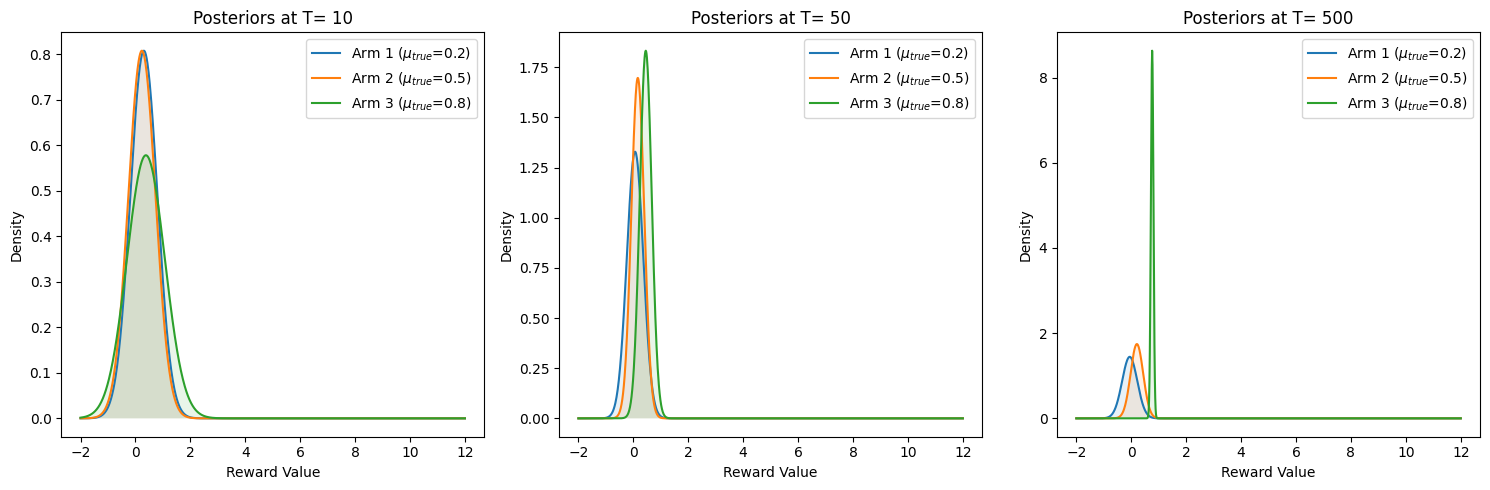

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ۱. پارامترهای محیط (طبق صورت سوال)
true_means = [0.2, 0.5,0.8] 
sigma_reward = 1.0            
k = len(true_means)

mu_hat = np.zeros(k)          
sigma_sq = np.ones(k) * 10    

# زمان هایی که می خواهیم وضعیت توزیع را چک کنیم
checkpoints = [10, 50, 500]
x_axis = np.linspace(-2, 12, 1000)



plt.figure(figsize=(15, 5))

for i, T_limit in enumerate(checkpoints):
    current_t = 0 if i == 0 else checkpoints[i-1]
    
    for t in range(current_t, T_limit):
        # بخش آ: نمونه گیری از توزیع فعلی (Sampling)
        thetas = [np.random.normal(mu_hat[j], np.sqrt(sigma_sq[j])) for j in range(k)]
        
        # بخش ب: انتخاب بازوی بهینه در این لحظه
        chosen_arm = np.argmax(thetas)
        
        # بخش ج: مشاهده پاداش واقعی از محیط
        reward = np.random.normal(true_means[chosen_arm], sigma_reward)
        
        old_var = sigma_sq[chosen_arm]
        # فرمول به روزرسانی واریانس پسین
        new_var = 1 / (1/old_var + 1/sigma_reward**2)
        # فرمول به روزرسانی میانگین پسین
        new_mean = (mu_hat[chosen_arm]/old_var + reward/sigma_reward**2) * new_var
        
        mu_hat[chosen_arm] = new_mean
        sigma_sq[chosen_arm] = new_var

    plt.subplot(1, 3, i+1)
    for j in range(k):
        y = norm.pdf(x_axis, mu_hat[j], np.sqrt(sigma_sq[j]))
        plt.plot(x_axis, y, label=f'Arm {j+1} ($\mu_{{true}}$={true_means[j]})')
        plt.fill_between(x_axis, 0, y, alpha=0.1)
    
    plt.title(f'Posteriors at T= {T_limit}')
    plt.xlabel('Reward Value')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()